In [9]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout,UpSampling2D, LeakyReLU, BatchNormalization
from tensorflow.keras.utils import plot_model
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models


### load the dataset

In [10]:
df_train = pd.read_csv("/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train.csv")
df_test = pd.read_csv("/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test.csv")


### basic Info

In [11]:
df_train.shape

(39209, 8)

In [12]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39209 entries, 0 to 39208
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Width    39209 non-null  int64 
 1   Height   39209 non-null  int64 
 2   Roi.X1   39209 non-null  int64 
 3   Roi.Y1   39209 non-null  int64 
 4   Roi.X2   39209 non-null  int64 
 5   Roi.Y2   39209 non-null  int64 
 6   ClassId  39209 non-null  int64 
 7   Path     39209 non-null  object
dtypes: int64(7), object(1)
memory usage: 2.4+ MB


In [13]:
df_train.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [14]:
df_train.describe()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId
count,39209.000000,39209.000000,39209.000000,39209.000000,39209.000000,39209.000000,39209.000000
mean,50.835880,50.328930,5.999515,5.962381,45.197302,44.728379,15.788390
std,24.306933,23.115423,1.475493,1.385440,23.060157,21.971145,12.013238
min,25.000000,25.000000,0.000000,5.000000,20.000000,20.000000,0.000000
25%,35.000000,35.000000,5.000000,5.000000,29.000000,30.000000,5.000000
50%,43.000000,43.000000,6.000000,6.000000,38.000000,38.000000,12.000000
75%,58.000000,58.000000,6.000000,6.000000,53.000000,52.000000,25.000000
max,243.000000,225.000000,20.000000,20.000000,223.000000,205.000000,42.000000


### variable Distributions|

<Axes: xlabel='Width', ylabel='Count'>

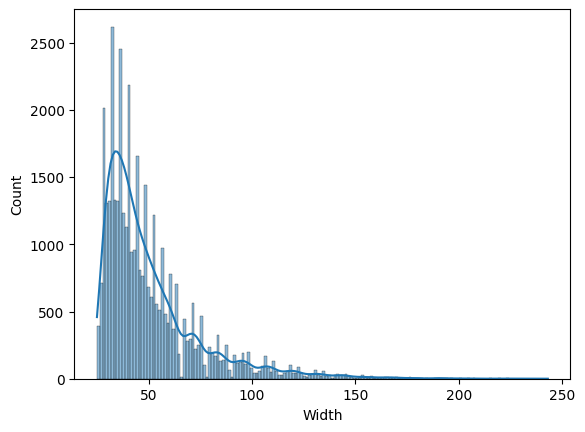

In [15]:
sns.histplot(data = df_train, x = 'Width', kde = True)

<Axes: xlabel='Height', ylabel='Count'>

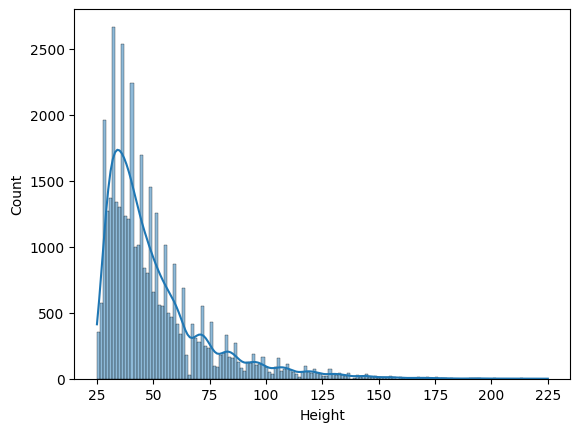

In [16]:
sns.histplot(data = df_train, x = 'Height', kde = True)

Text(0, 0.5, 'Count')

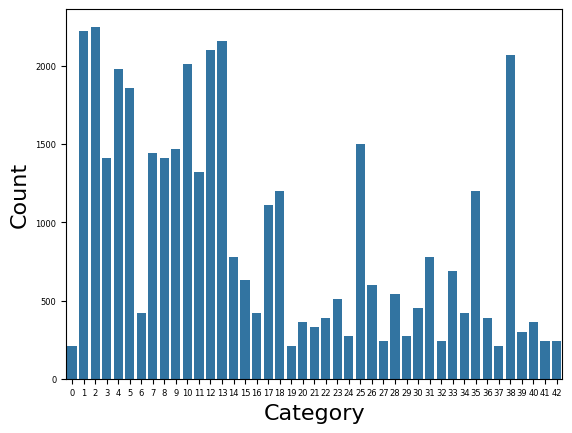

In [17]:
ax = sns.countplot(data = df_train, x = 'ClassId')
ax.tick_params(axis='both', labelsize=6)
ax.set_xlabel('Category', fontsize=16)
ax.set_ylabel('Count', fontsize=16)

In [18]:
value_count = df_train['ClassId'].value_counts() / len(df_train)
print(value_count.sort_values(ascending= False))

ClassId
2     0.057385
1     0.056620
13    0.055089
12    0.053559
38    0.052794
10    0.051264
4     0.050499
5     0.047438
25    0.038257
9     0.037491
7     0.036726
3     0.035961
8     0.035961
11    0.033666
35    0.030605
18    0.030605
17    0.028310
14    0.019893
31    0.019893
33    0.017572
15    0.016068
26    0.015303
28    0.013772
23    0.013007
30    0.011477
6     0.010712
16    0.010712
34    0.010712
22    0.009947
36    0.009947
20    0.009182
40    0.009182
21    0.008416
39    0.007651
29    0.006886
24    0.006886
42    0.006121
32    0.006121
27    0.006121
41    0.006121
0     0.005356
19    0.005356
37    0.005356
Name: count, dtype: float64


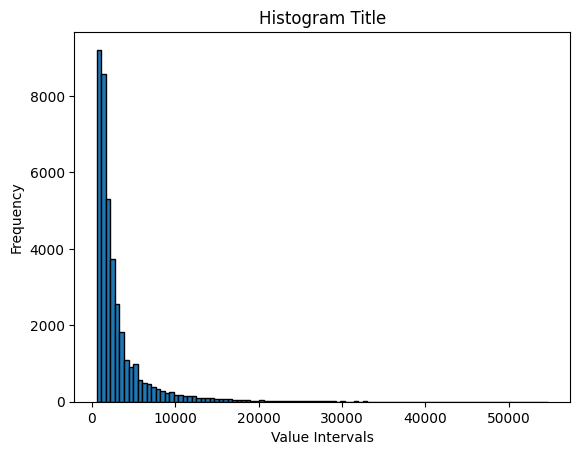

In [19]:
plt.hist(df_train["Height"]*df_train["Width"], bins=100, edgecolor='black')
plt.title('Histogram Title')
plt.xlabel('Value Intervals')
plt.ylabel('Frequency')
plt.show()

### Load Images

In [20]:
base_path = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"
def load_images(df, target_size=(32, 32)):
    images = []
    labels = []
    for idx in range(df.shape[0]):
        roi = df.iloc[idx,2:6]
        img_path = os.path.join(base_path,df.loc[idx,"Path"])
        with Image.open(img_path) as img:
            crop_box = (roi["Roi.X1"],roi["Roi.Y1"],roi["Roi.X2"],roi["Roi.Y2"])
            img = img.crop(crop_box)
            img = img.resize(target_size)
            images.append(img)
            labels.append(df.loc[idx,"ClassId"])
    return np.array(images), np.array(labels)


In [21]:
X_train,y_train = load_images(df_train)
X_test,y_test = load_images(df_test)

In [22]:
print(len(X_train), len(y_train))

39209 39209


### Sample Img per class

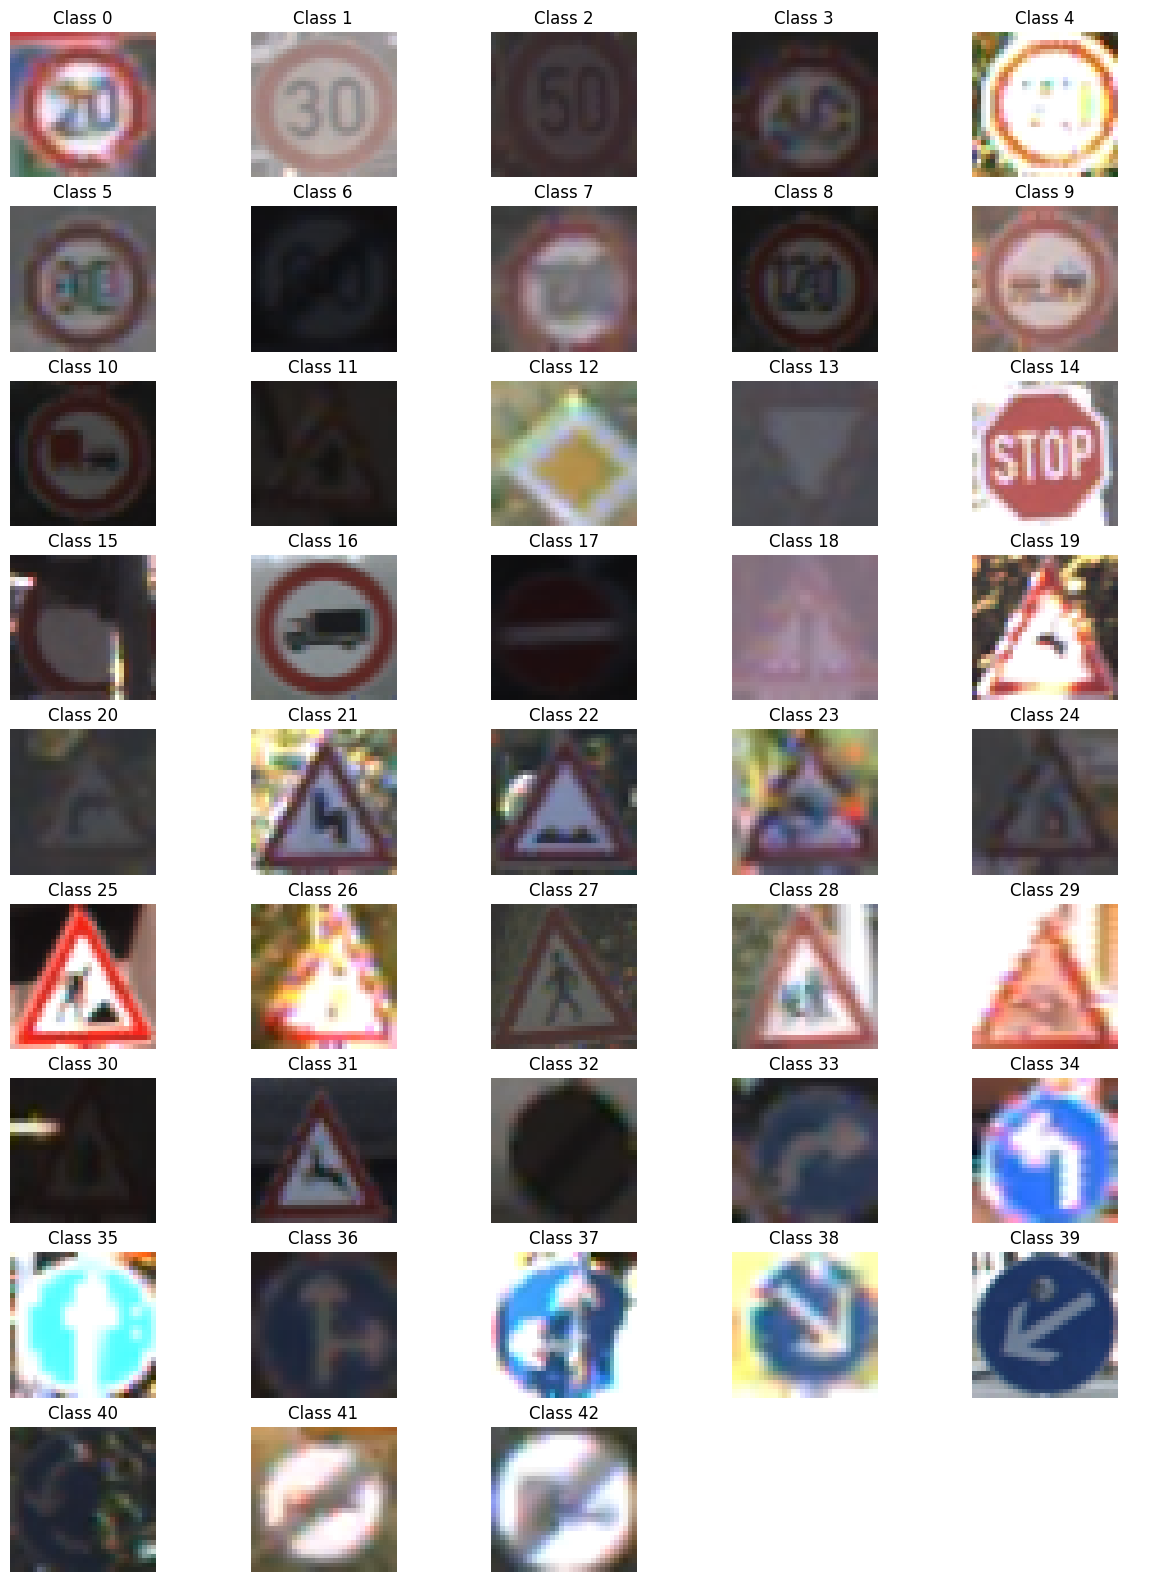

In [23]:
fig, axes = plt.subplots(9, 5, figsize= (15, 20))
for i, ax in enumerate(axes.flatten()):
  if i > 42:
    ax.axis('off')
    continue
  img = X_train[y_train == i][0]
  ax.imshow(img)
  ax.set_title(f'Class {i}')
  ax.axis('off')

### Pixels stats

In [24]:
def pixel_stats(X):

  flatten_img = X.flatten()
  Stats = {
      'mean': [np.mean(flatten_img)],
      'median': [np.median(flatten_img)],
      'std': [np.std(flatten_img)],
      'max': [np.max(flatten_img)],
      'min': [np.min(flatten_img)],
  }
  return pd.DataFrame(Stats)

In [25]:
stats = pixel_stats(X_train)
stats = stats.T.rename(columns={0: 'value'})
print(stats)

             value
mean     85.972866
median   63.000000
std      68.114775
max     255.000000
min       0.000000


In [26]:
#Flattening
images = X_train.reshape(X_train.shape[0], -1)
labels = y_train
images = images / 255
scaler = StandardScaler()
images_scaled = scaler.fit_transform(images)

In [27]:
#PCA implementation
pca = PCA(n_components=100)
image_pca = pca.fit_transform(images_scaled)
print(image_pca.shape)

#LDA implementation
lda = LDA(n_components=2)
image_lda = lda.fit_transform(image_pca, labels)
print(image_lda.shape)

(39209, 100)
(39209, 2)


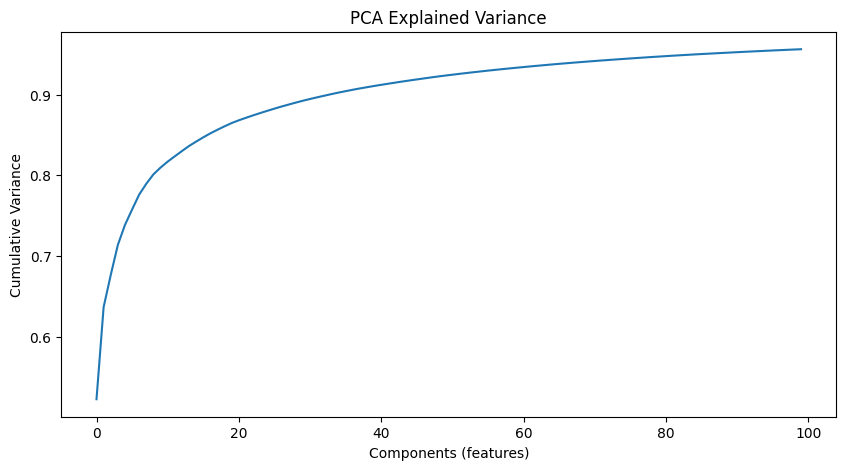

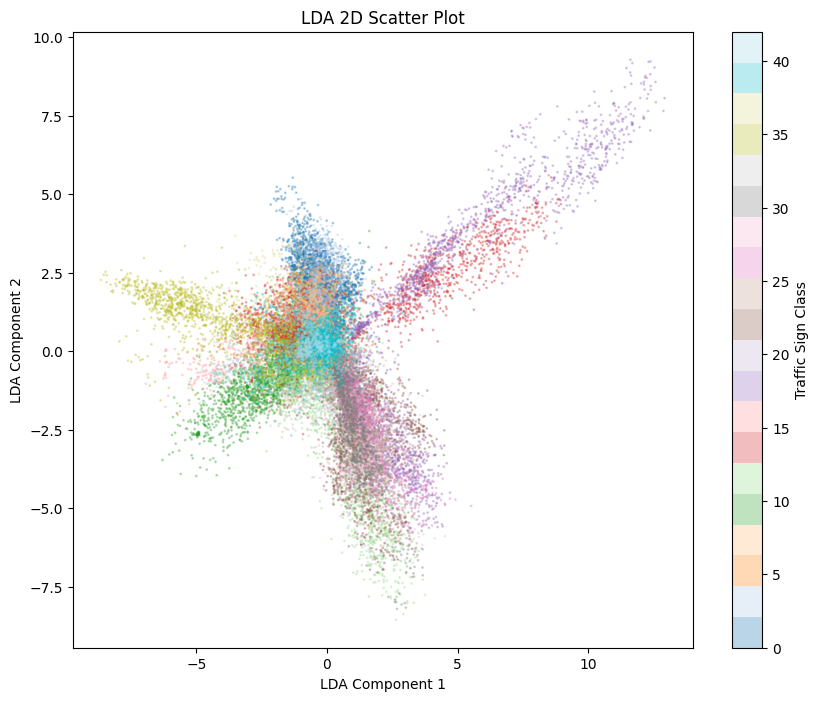

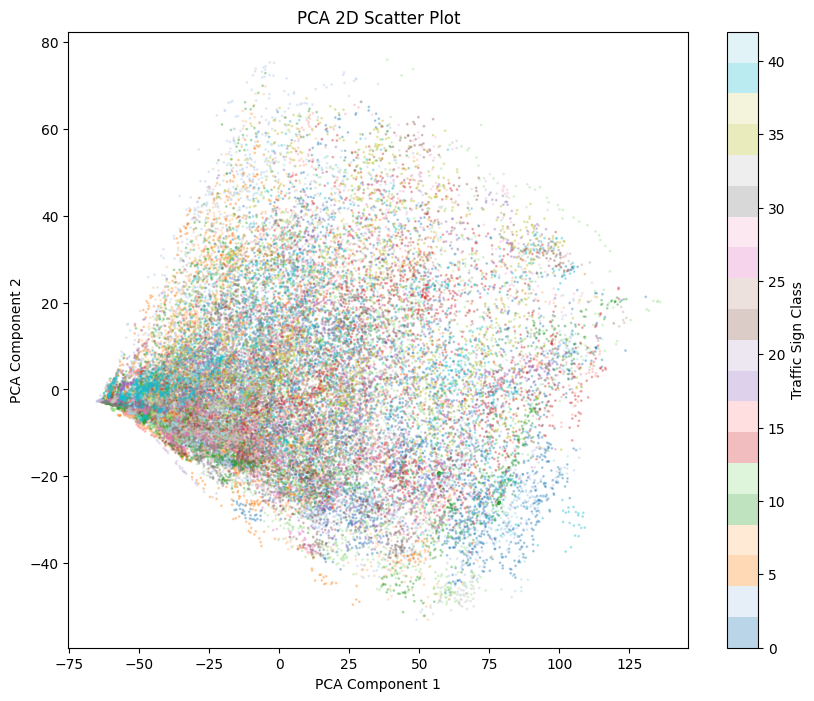

In [28]:
#Plot 1 : PCA explained variance
plt.figure(figsize=(10,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.title('PCA Explained Variance')
plt.xlabel('Components (features)')
plt.ylabel('Cumulative Variance')
plt.show()

#Plot 2 : LDA 2D Scatter Plot
plt.figure(figsize=(10,8))
plt.scatter(image_lda[:,0], image_lda[:,1], c=labels, cmap='tab20', alpha=0.3, s=1)
plt.title('LDA 2D Scatter Plot')
plt.xlabel('LDA Component 1')
plt.ylabel('LDA Component 2')
plt.colorbar(label='Traffic Sign Class')
plt.show()


#Plot 3 : PCA 2D Scatter Plot
plt.figure(figsize=(10,8))
plt.scatter(image_pca[:,0], image_pca[:,1], c=labels, cmap='tab20', alpha=0.3, s=1)
plt.title('PCA 2D Scatter Plot')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Traffic Sign Class')
plt.show()

In [29]:



# Flatten and scale test images the same way as training
X_test_flat = X_test.reshape(X_test.shape[0], -1) / 255
X_test_scaled = scaler.transform(X_test_flat)

In [30]:



# -------------------------
# 1. Naive Bayes Classifier
# -------------------------
nb_clf = GaussianNB()
nb_clf.fit(images_scaled, labels)
y_pred_nb = nb_clf.predict(X_test_scaled)

print("=== Naive Bayes Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))


=== Naive Bayes Performance ===
Accuracy: 0.19034045922406967

Classification Report:
               precision    recall  f1-score   support

           0       0.04      0.37      0.08        60
           1       0.30      0.30      0.30       720
           2       0.23      0.11      0.15       750
           3       0.12      0.24      0.16       450
           4       0.00      0.00      0.00       660
           5       0.15      0.19      0.17       630
           6       0.04      0.76      0.07       150
           7       0.09      0.10      0.09       450
           8       0.07      0.08      0.07       450
           9       0.64      0.14      0.22       480
          10       0.00      0.00      0.00       660
          11       0.52      0.03      0.05       420
          12       0.99      0.19      0.31       690
          13       0.53      0.46      0.49       720
          14       0.86      0.44      0.58       270
          15       0.40      0.32      0.36     

In [31]:


# -------------------------
# 2. KNN Classifier
# -------------------------
knn_clf = KNeighborsClassifier(n_neighbors=5)  # you can tune k
knn_clf.fit(images_scaled, labels)
y_pred_knn = knn_clf.predict(X_test_scaled)

print("=== KNN Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

=== KNN Performance ===
Accuracy: 0.5577197149643706

Classification Report:
               precision    recall  f1-score   support

           0       0.25      0.27      0.26        60
           1       0.43      0.45      0.44       720
           2       0.37      0.37      0.37       750
           3       0.29      0.32      0.31       450
           4       0.48      0.52      0.50       660
           5       0.30      0.47      0.37       630
           6       0.58      0.51      0.55       150
           7       0.34      0.36      0.35       450
           8       0.39      0.36      0.37       450
           9       0.69      0.51      0.58       480
          10       0.76      0.75      0.76       660
          11       0.60      0.50      0.54       420
          12       0.92      0.76      0.83       690
          13       0.95      0.97      0.96       720
          14       0.99      0.72      0.83       270
          15       0.79      0.65      0.71       210
   

In [32]:
print(len(X_train), len(y_train))

39209 39209


In [33]:
from tensorflow.keras import Input
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Normalize images for CNN
X_train_cnn = X_train / 255.0
X_test_cnn = X_test / 255.0

model = Sequential([
    Input(shape=(32,32,3)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(43, activation='softmax')
])

model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

2026-05-13 13:41:18.263961: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 629,739 (2.40 MB)

 Trainable params: 629,291 (2.40 MB)

 Non-trainable params: 448 (1.75 KB)

In [34]:
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-5
)

In [35]:
print(len(X_train_cnn), len(y_train))

39209 39209


In [36]:
# Split
X_train_cnn, X_val_cnn, y_train, y_val = train_test_split(
    X_train_cnn, y_train, test_size=0.2, random_state=42
)

In [37]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator



# Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1
)

datagen.fit(X_train_cnn)

# Training
history = model.fit(
    datagen.flow(X_train_cnn, y_train, batch_size=64),
    epochs=30,
    validation_data=(X_val_cnn, y_val),
    callbacks=[early_stop, reduce_lr]
)

# Test
test_loss, test_acc = model.evaluate(X_test_cnn, y_test)
print(test_acc)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


491/491 ━━━━━━━━━━━━━━━━━━━━ 63s 122ms/step - accuracy: 0.2937 - loss: 2.7333 - val_accuracy: 0.7549 - val_loss: 0.7549 - learning_rate: 0.0010
Epoch 2/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 62s 127ms/step - accuracy: 0.7673 - loss: 0.7177 - val_accuracy: 0.9688 - val_loss: 0.0973 - learning_rate: 0.0010
Epoch 3/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 63s 128ms/step - accuracy: 0.9047 - loss: 0.3020 - val_accuracy: 0.9833 - val_loss: 0.0544 - learning_rate: 0.0010
Epoch 4/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 61s 124ms/step - accuracy: 0.9396 - loss: 0.2006 - val_accuracy: 0.9908 - val_loss: 0.0279 - learning_rate: 0.0010
Epoch 5/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 62s 126ms/step - accuracy: 0.9507 - loss: 0.1580 - val_accuracy: 0.9850 - val_loss: 0.0523 - learning_rate: 0.0010
Epoch 6/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 61s 124ms/step - accuracy: 0.9571 - loss: 0.1405 - val_accuracy: 0.9901 - val_loss: 0.0378 - learning_rate: 0.0010
Epoch 7/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 60s 123ms/step - accuracy: 0.9665 - loss:

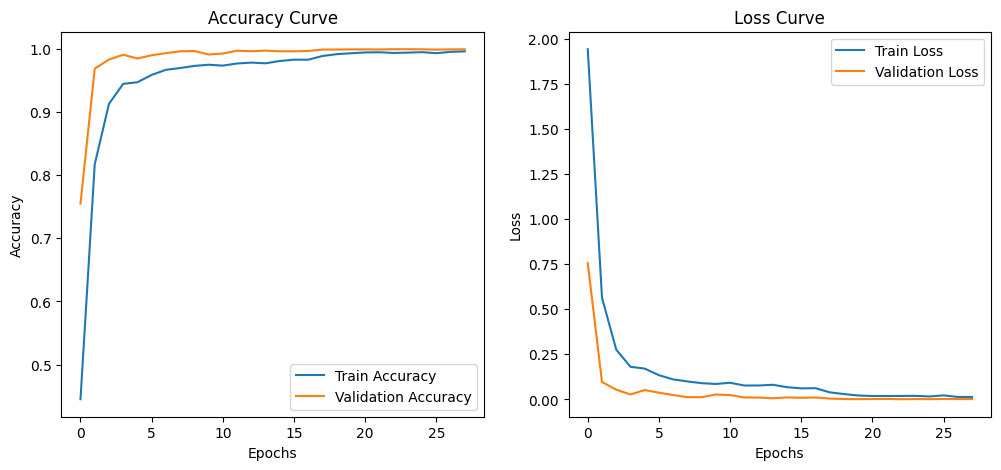

In [38]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [39]:
plot_model(model, to_file='cnn_architecture.png', show_shapes=True, show_layer_names=True)
test_loss, test_acc = model.evaluate(X_test_cnn, y_test)
print("CNN Test Accuracy:", test_acc)

395/395 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9840 - loss: 0.0937
CNN Test Accuracy: 0.9840063452720642


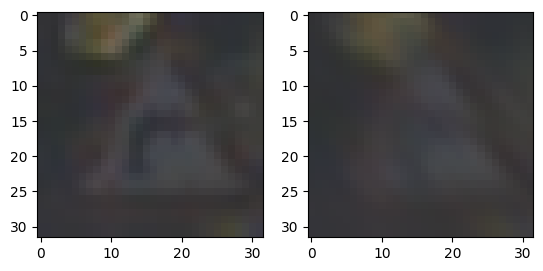

In [40]:
import cv2

def apply_custom_kernel(image, kernel_matrix):
    kernel = np.array(kernel_matrix, dtype=np.float32)
    return cv2.filter2D(image, -1, kernel)

motion_blur_kernel = [
    [0.2, 0, 0, 0, 0],
    [0, 0.2, 0, 0, 0],
    [0, 0, 0.2, 0, 0],
    [0, 0, 0, 0.2, 0],
    [0, 0, 0, 0, 0.2]
]

new_img = apply_custom_kernel(X_train[0],motion_blur_kernel)
plt.subplot(121)
plt.imshow(X_train[0])
plt.subplot(122)
plt.imshow(new_img)

In [41]:
def add_noise(data):
    noised_data = []
    for img in data:
        noised_data.append(np.clip(apply_custom_kernel(img,motion_blur_kernel),0,255).astype(np.uint8))
    return np.array(noised_data)

In [42]:
y_train_denoise = X_train.copy()
x_train_denoise = add_noise(y_train_denoise)
x_train_denoise = x_train_denoise/255
y_train_denoise = y_train_denoise/255
x_train_denoise = x_train_denoise.reshape(-1,32,32,3)
y_train_denoise = y_train_denoise.reshape(-1,32,32,3)

In [43]:
autoencoder_model =  Sequential([
    Conv2D(32, (3,3), padding="same",input_shape=(32,32,3)),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    MaxPooling2D((2,2),strides=2),
    Conv2D(64, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    Conv2D(64, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    Conv2D(128, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    UpSampling2D(size=(2,2)),
    Conv2D(64, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    Conv2D(64, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    UpSampling2D(size=(2,2)),
    Conv2D(32, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    Conv2D(3, (3,3),activation="sigmoid",padding="same")
])
autoencoder_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,92

 Total params: 410,115 (1.56 MB)

 Trainable params: 408,963 (1.56 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [44]:
autoencoder_model.compile(optimizer="adam",loss="mse",metrics=["mae"])
history = autoencoder_model.fit(x_train_denoise,y_train_denoise,batch_size=32,epochs=20)

Epoch 1/20
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 345s 276ms/step - loss: 0.0098 - mae: 0.0656
Epoch 2/20
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 334s 272ms/step - loss: 0.0034 - mae: 0.0406
Epoch 3/20
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 331s 270ms/step - loss: 0.0025 - mae: 0.0343
Epoch 4/20
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 352s 287ms/step - loss: 0.0021 - mae: 0.0312
Epoch 5/20
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 342s 279ms/step - loss: 0.0019 - mae: 0.0295
Epoch 6/20
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 341s 278ms/step - loss: 0.0019 - mae: 0.0291
Epoch 7/20
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 347s 283ms/step - loss: 0.0017 - mae: 0.0274
Epoch 8/20
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 334s 272ms/step - loss: 0.0016 - mae: 0.0265
Epoch 9/20
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 349s 285ms/step - loss: 0.0015 - mae: 0.0256
Epoch 10/20
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 340s 278ms/step - loss: 0.0014 - mae: 0.0249
Epoch 11/20
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 338s 276ms/step - loss: 0.0015 - mae: 0.0261
Epoch 12/20
1226/1226 ━━━━━━━━━━━━━━━━━━━

KeyboardInterrupt: 

In [ ]:
autoencoder_model.save("/kaggle/working/autoencoder_model.keras")

In [ ]:
print(f'number of classes: {len(np.unique(y_train))}')

In [45]:
IMG_SIZE = (96, 96)
CHANNELS = 3
NUM_CLASSES = 43
X_train_scaled = (X_train / 127.5) - 1.0
X_test_scaled = (X_test / 127.5) - 1.0
base_model_pretrained = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS))
base_model_pretrained.trainable = False 
pre_trained = models.Sequential([
    layers.Resizing(IMG_SIZE[0], IMG_SIZE[1]),
    
    base_model_pretrained,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(NUM_CLASSES, activation='softmax')
])


pre_trained.compile(tf.keras.optimizers.legacy.Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Starting Training: Pretrained Model...")
history_pretrained = pre_trained.fit(X_train_scaled, y_train, batch_size=32,epochs=10, validation_data=(X_test_scaled, y_test))

base_model_tuning = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS))
base_model_tuning.trainable = True

fine_tune_at = 100
for layer in base_model_tuning.layers[:fine_tune_at]:
    layer.trainable = False

tuning= models.Sequential([
    layers.Resizing(IMG_SIZE[0], IMG_SIZE[1]),
    
    base_model_tuning,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
tuning.compile(optimizer=tf.keras.optimizers.legacy.Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Starting Training: Fine-tuning...")
history_finetuned = tuning.fit(X_train_scaled, y_train, batch_size=32, epochs=10, validation_data=(X_test_scaled, y_test))

Exception: URL fetch failure on https://storage.googleapis.com/tensorflow/keras-applications/mobilenet_v2/mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_96_no_top.h5: None -- [Errno -3] Temporary failure in name resolution

## Pretrained vs fine-tuned
| Model State | Optimizer | Training Loss | Training Accuracy | Validation Loss | validation Accuracy |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Pretrained (Frozen)** | Adam | 0.1948 | 0.9325 | 0.8452  | 0.7967 |
| **Fine-tuned (Unfrozen)** | Adam | 0.0182  | 0.9944  | 0.2067  | 0.9618 |

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

optimizers_to_test = {
    'SGD': tf.keras.optimizers.legacy.SGD(learning_rate=0.01,momentum=0.9),
    'Adam': tf.keras.optimizers.legacy.Adam(learning_rate=0.001),
    'RMSprop': tf.keras.optimizers.legacy.RMSprop(learning_rate=0.001)
}

histories = {}
results = {}

for opt_name,opt in optimizers_to_test.items():
    print(f"Training with {opt_name} ")

    m = Sequential([
        Input(shape=(32, 32, 3)),

        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3),activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(128,(3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),

        Dense(43, activation='softmax')
    ])

    m.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-5
    )

    datagen = ImageDataGenerator(
        rotation_range=15,
        zoom_range=0.2,
        width_shift_range=0.15,
        height_shift_range=0.15,
        shear_range=0.1
    )

    datagen.fit(X_train_cnn)

    history = m.fit(
        datagen.flow(X_train_cnn, y_train, batch_size=64),
        epochs=30,
        validation_data=(X_val_cnn, y_val),
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    loss, acc = m.evaluate(X_test_cnn, y_test, verbose=0)

    histories[opt_name] = history
    results[opt_name] = {
        'Test Accuracy': round(acc, 4),
        'Test Loss': round(loss, 4)
    }

    print(f"{opt_name} : Test Accuracy: {acc:.4f}")


# Training Curves 

colors = {'SGD': 'red', 'Adam': 'blue', 'RMSprop': 'green'}
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)

for name, h in histories.items():
    plt.plot(h.history['accuracy'], label=name,color=colors[name])
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
for name, h in histories.items():
    plt.plot(h.history['val_accuracy'],label=name, color=colors[name])
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


# Metrics Table

rows = []
for name, h in histories.items():
    rows.append({
        'Optimizer': name,
        'Final Train Acc': round(h.history['accuracy'][-1], 4),
        'Final Val Acc': round(h.history['val_accuracy'][-1], 4),
        'Best Val Acc': round(max(h.history['val_accuracy']), 4),
        'Best Val Epoch': int(np.argmax(h.history['val_accuracy'])) + 1,
        'Test Accuracy': results[name]['Test Accuracy'],
        'Test Loss': results[name]['Test Loss'],
    })

df_optimizers = pd.DataFrame(rows).set_index('Optimizer')
print(df_optimizers)

**RNN**

X_train_rnn: (39209, 32, 96)
X_test_rnn:  (12630, 32, 96)
y_train_cat: (39209, 43)
y_test_cat:  (12630, 43)

X_tr:  (31367, 32, 96)
X_val: (7842, 32, 96)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_5 (SimpleRNN)        │ (None, 32, 128)        │        28,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,019 (214.92 KB)

 Trainable params: 55,019 (214.92 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.2421 - loss: 2.7383 - val_accuracy: 0.5691 - val_loss: 1.3260 - learning_rate: 0.0010
Epoch 2/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.6058 - loss: 1.2439 - val_accuracy: 0.7363 - val_loss: 0.7932 - learning_rate: 0.0010
Epoch 3/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.7136 - loss: 0.9256 - val_accuracy: 0.8282 - val_loss: 0.5666 - learning_rate: 0.0010
Epoch 4/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.7859 - loss: 0.7188 - val_accuracy: 0.8717 - val_loss: 0.4375 - learning_rate: 0.0010
Epoch 5/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.8062 - loss: 0.6791 - val_accuracy: 0.9211 - val_loss: 0.3000 - learning_rate: 0.0010
Epoch 6/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.8416 - loss: 0.5650 - val_accuracy: 0.8871 - val_loss: 0.3948 - learning_rate: 0.0010
Epoch 7/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.8413 - l

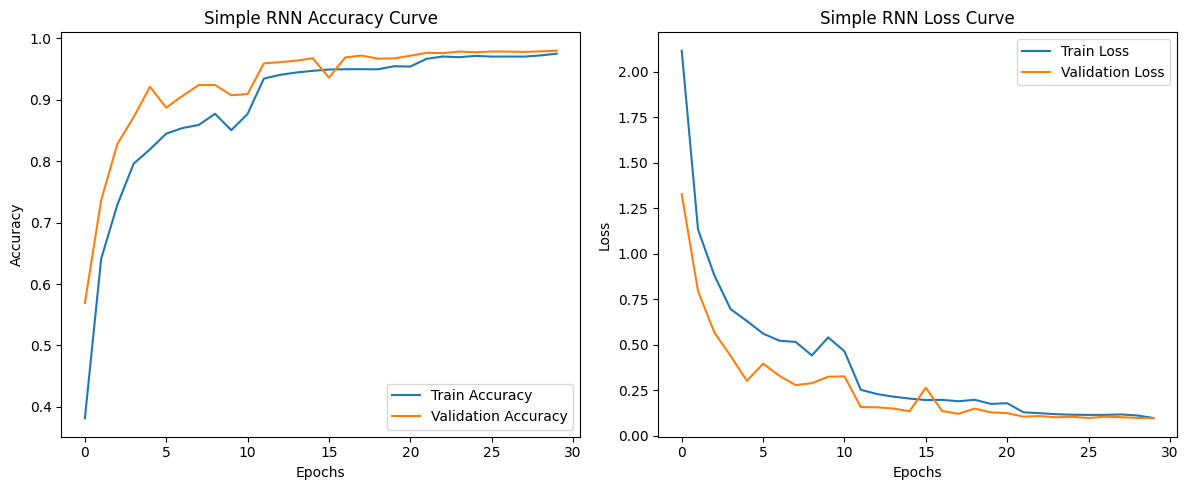

Simple RNN Test Accuracy: 0.9198
Simple RNN Test Loss:     0.3758


In [56]:
# ============================================================
# Simple RNN - Traffic Sign Classification
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ── 1. Prepare Data ────────────────────────────────────────
X_train_rnn = X_train.reshape(-1, 32, 96).astype('float32') / 255.0
X_test_rnn  = X_test.reshape(-1, 32, 96).astype('float32') / 255.0

y_train_cat = to_categorical(df_train["ClassId"].values, num_classes=43)
y_test_cat  = to_categorical(df_test["ClassId"].values,  num_classes=43)

print(f"X_train_rnn: {X_train_rnn.shape}")  # (39209, 32, 96)
print(f"X_test_rnn:  {X_test_rnn.shape}")   # (12630, 32, 96)
print(f"y_train_cat: {y_train_cat.shape}")  # (39209, 43)
print(f"y_test_cat:  {y_test_cat.shape}")   # (12630, 43)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_rnn, y_train_cat, test_size=0.2, random_state=42
)

print(f"\nX_tr:  {X_tr.shape}")
print(f"X_val: {X_val.shape}")

# ── 2. Build Model ─────────────────────────────────────────
rnn_model = Sequential([
    SimpleRNN(128, input_shape=(32, 96), return_sequences=True),
    Dropout(0.3),

    SimpleRNN(64, return_sequences=False),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(43, activation='softmax')
])

rnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

# ── 3. Train ───────────────────────────────────────────────
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-5)

history_rnn = rnn_model.fit(
    X_tr, y_tr,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ── 4. Plot ────────────────────────────────────────────────
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_rnn.history['accuracy'],     label='Train Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Simple RNN Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_rnn.history['loss'],     label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.title('Simple RNN Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# ── 5. Evaluate ────────────────────────────────────────────
test_loss, test_acc = rnn_model.evaluate(X_test_rnn, y_test_cat, verbose=0)
print(f"Simple RNN Test Accuracy: {test_acc:.4f}")
print(f"Simple RNN Test Loss:     {test_loss:.4f}")

**LSTM**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
import pandas as pd

X_train_lstm = X_train.reshape(X_train.shape[0], 32, 96).astype('float32') / 255.0
X_test_lstm = X_test.reshape(X_test.shape[0], 32, 96).astype('float32') / 255.0

#1-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=43)
y_test_cat = to_categorical(y_test, num_classes=43)

# split validation set
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val_cat = train_test_split(
    X_train_lstm, y_train_cat, test_size=0.2, random_state=42
)

print("X_train shape:", X_tr.shape)
print("X_test shape: ", X_test_lstm.shape)


In [ ]:
#Building 

lstm_model = Sequential([
    LSTM(128, input_shape=(32, 96), return_sequences=True),
    Dropout(0.3),

    LSTM(64, return_sequences=False),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(43, activation='softmax')
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

In [ ]:
#Training 

early_stop = EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-5)

history = lstm_model.fit(
    X_tr, y_tr,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val_cat),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


In [ ]:
#Plotting training curves 

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
#Evaluation

test_loss, test_acc = lstm_model.evaluate(X_test_lstm, y_test_cat, verbose=0)
print(f"LSTM Test Accuracy: {test_acc:.4f}")
print(f"LSTM Test Loss: {test_loss:.4f}")